# Convolutional Neural Networks for Image Classification
## Fine-Tuning a CNN

This notebook implements **fine-tuning** of a pre-trained AlexNet (ImageNet) for CIFAR-10 classification.

Fine-tuning is a **transfer learning** strategy:
- The pre-trained backbone weights are transferred and updated with a **small learning rate**.
- The final classification layer is **randomly initialised** (different class count) and trained with a **higher learning rate**.
- Early convolutional layers (which learn generic low-level features) can optionally be **frozen**.

This approach combines the representational power of a large pre-trained model with adaptation to the target dataset.

### 1. Imports & Device Configuration

In [1]:
# Basic imports
import time, os, sys, numpy as np
import torch
import torchvision
import torch.nn as nn
import torch.nn.functional as F
from torch import optim
from torchsummary import summary
import time, os, sys, numpy as np
# Test if GPU is avaliable, if not, use cpu instead
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
n = torch.cuda.device_count()
devices_ids = list(range(n))
print('Using device:', device)

Using device: cpu


### 2. Data Loading & Helper Functions

Reusing the same `load_data_cifar10`, `evaluate_accuracy`, and `train_validate` functions from cifar10-dataloader.ipynb.

In [2]:
def load_data_cifar10(batch_size, resize=None, root=os.path.join(
    '~', '.pytorch', 'datasets', 'fashion-mnist')):
    """Download the Cifar10 dataset and then load into memory."""
    root = os.path.expanduser(root)
    transformer = []
    if resize:
        transformer += [torchvision.transforms.Resize(resize)]
    transformer += [torchvision.transforms.ToTensor()]
    transformer = torchvision.transforms.Compose(transformer)
    mnist_train = torchvision.datasets.CIFAR10(
        root=root, train=True, download=True, transform=transformer)
    mnist_test = torchvision.datasets.CIFAR10(
        root=root, train=False, download=True, transform=transformer)
    num_workers = 0 if sys.platform.startswith('win32') else 4
    train_iter = torch.utils.data.DataLoader(
        mnist_train, batch_size, shuffle=True, num_workers=num_workers)
    test_iter = torch.utils.data.DataLoader(
        mnist_test, batch_size, shuffle=False, num_workers=num_workers)
    return train_iter, test_iter


def evaluate_accuracy(data_iter, net, loss):
    """Evaluate accuracy of a model on the given data set."""
    acc_sum, n, l = torch.Tensor([0]), 0, 0
    net.eval()
    with torch.no_grad():
        for X, y in data_iter:
            X, y = X.to(device), y.to(device)
            y_hat = net(X)
            l += loss(y_hat, y).sum()
            acc_sum += (y_hat.argmax(axis=1) == y).sum().item()
            n += y.size()[0]
    return acc_sum.item() / n, l.item() / len(data_iter)


def train_validate(net, train_iter, test_iter, batch_size, trainer, loss, num_epochs):
    print('training on', device)
    history = []
    for epoch in range(num_epochs):
        net.train()
        train_l_sum, train_acc_sum, n, start = 0.0, 0.0, 0, time.time()
        for X, y in train_iter:
            X, y = X.to(device), y.to(device)
            y_hat = net(X)
            trainer.zero_grad()
            l = loss(y_hat, y).sum()
            l.backward()
            trainer.step()
            train_l_sum += l.item()
            train_acc_sum += (y_hat.argmax(axis=1) == y).sum().item()
            n += y.size()[0]
        test_acc, test_loss = evaluate_accuracy(test_iter, net, loss)
        train_loss = train_l_sum / len(train_iter)
        train_acc = train_acc_sum / n
        history.append({
            'epoch': epoch + 1,
            'train_loss': train_loss,
            'train_acc': train_acc,
            'test_loss': test_loss,
            'test_acc': test_acc,
        })
        print('epoch %d, train loss %.4f, train acc %.3f, test loss %.4f, '
              'test acc %.3f, time %.1f sec'
              % (epoch + 1, train_loss, train_acc, test_loss,
                 test_acc, time.time() - start))
    return history

### 3. Fine-Tuning AlexNet on CIFAR-10

**Strategy:**
- Load AlexNet pre-trained on ImageNet.
- Freeze the convolutional feature extraction layers (`net.features`) — these encode generic low-level patterns.
- Keep all fully-connected layers trainable, including the newly replaced classification head.
- Use **two different learning rates** via parameter groups:
  - `lr = 0.0001` for the FC backbone layers (small, incremental adjustments to pre-trained weights)
  - `lr = 0.001` for the new classification layer (higher, randomly initialised — needs to learn from scratch)

This is the key difference from alexnet-model-training.ipynb (3), where the backbone was fully frozen.

In [3]:
import warnings
warnings.filterwarnings('ignore')  # suppress pretrained= deprecation warning

# Step 1: Instantiate pre-trained AlexNet
net = torchvision.models.alexnet(pretrained=True)

# Step 2: Change the last layer to output 10 classes instead of 1000
num_ftrs = net.classifier[6].in_features
net.classifier[6] = nn.Linear(num_ftrs, 10)

# Step 3: Freeze the convolutional layers (net.features)
# These learn generic edges/textures — useful across datasets, no need to retrain
for param in net.features.parameters():
    param.requires_grad = False

# Step 4: Send model to device
net.to(device)

# Print architecture and parameter summary
print("--- Fine-Tuning AlexNet Architecture ---")
print(net)
print(summary(net, (3, 227, 227)))

# Show which layers will be updated
print("\nTrainable parameters:")
for name, param in net.named_parameters():
    if param.requires_grad:
        print(f"  {name}")

--- Fine-Tuning AlexNet Architecture ---
AlexNet(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(11, 11), stride=(4, 4), padding=(2, 2))
    (1): ReLU(inplace=True)
    (2): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(64, 192, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
    (4): ReLU(inplace=True)
    (5): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(192, 384, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU(inplace=True)
    (8): Conv2d(384, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): ReLU(inplace=True)
    (10): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (avgpool): AdaptiveAvgPool2d(output_size=(6, 6))
  (classifier): Sequential(
    (0): Dropout(p=0.5, inplace=False)
    (1): Linear(in_featu

### 4. Training with Differential Learning Rates

The classifier backbone (`fc6`, `fc7`) receives a **10x smaller learning rate** than the new classification head (`fc8`), reflecting that the backbone weights are already well-initialised and need only fine adjustments.

In [4]:
num_epochs, batch_size, wd_lambda = 10, 100, 0.0001
lr_backbone = 0.0001  # small lr for pre-trained FC layers
lr_head     = 0.001   # higher lr for the new classification head

loss = nn.CrossEntropyLoss()

# Loading data: CIFAR-10 resized to 227x227 for AlexNet
train_iter, test_iter = load_data_cifar10(batch_size, resize=227)

# Differential learning rates:
#   - classifier[0..5] (fc6, fc7): pre-trained weights, small lr
#   - classifier[6]   (fc8): randomly initialised, higher lr
trainer = optim.Adam([
    {'params': net.classifier[0].parameters(), 'lr': lr_backbone},
    {'params': net.classifier[1].parameters(), 'lr': lr_backbone},
    {'params': net.classifier[3].parameters(), 'lr': lr_backbone},
    {'params': net.classifier[4].parameters(), 'lr': lr_backbone},
    {'params': net.classifier[6].parameters(), 'lr': lr_head},
], weight_decay=wd_lambda)

# Training and validation
history = train_validate(net, train_iter, test_iter, batch_size, trainer, loss, num_epochs)

Files already downloaded and verified
Files already downloaded and verified
training on cpu
epoch 1, train loss 0.9671, train acc 0.658, test loss 0.7697, test acc 0.728, time 395.4 sec
epoch 2, train loss 0.7459, train acc 0.736, test loss 0.6829, test acc 0.754, time 382.8 sec
epoch 3, train loss 0.6683, train acc 0.764, test loss 0.6591, test acc 0.770, time 383.1 sec
epoch 4, train loss 0.6111, train acc 0.784, test loss 0.5976, test acc 0.793, time 388.2 sec
epoch 5, train loss 0.5619, train acc 0.802, test loss 0.5644, test acc 0.808, time 384.4 sec
epoch 6, train loss 0.5213, train acc 0.816, test loss 0.5615, test acc 0.807, time 383.2 sec
epoch 7, train loss 0.4897, train acc 0.826, test loss 0.5489, test acc 0.814, time 389.2 sec
epoch 8, train loss 0.4573, train acc 0.836, test loss 0.5386, test acc 0.815, time 389.7 sec
epoch 9, train loss 0.4240, train acc 0.846, test loss 0.5403, test acc 0.816, time 389.5 sec
epoch 10, train loss 0.4019, train acc 0.855, test loss 0.5489

### 5. Training Curves

Loss and accuracy over epochs for fine-tuning with differential learning rates.

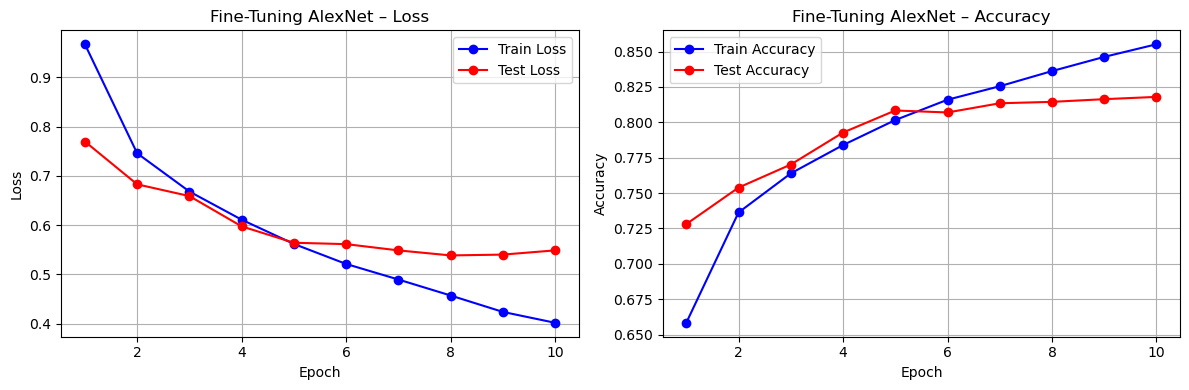

In [5]:
import matplotlib.pyplot as plt

epochs     = [h['epoch']      for h in history]
train_loss = [h['train_loss'] for h in history]
test_loss  = [h['test_loss']  for h in history]
train_acc  = [h['train_acc']  for h in history]
test_acc   = [h['test_acc']   for h in history]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(epochs, train_loss, 'b-o', label='Train Loss')
ax1.plot(epochs, test_loss,  'r-o', label='Test Loss')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('Fine-Tuning AlexNet – Loss')
ax1.legend()
ax1.grid(True)

ax2.plot(epochs, train_acc, 'b-o', label='Train Accuracy')
ax2.plot(epochs, test_acc,  'r-o', label='Test Accuracy')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.set_title('Fine-Tuning AlexNet – Accuracy')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()